# PROC BOX로 응급실 재원 시간 시각화하기

## 요약

PROC BOXPLOT(별칭 PROC BOX)을 사용하여 세 개 임상 진료과에 걸친 응급실 재원 시간을 비교하는 병원 운영 분석입니다. 나란히 배치된 개략(schematic) 상자 그림은 각 진료과의 중앙값, 사분위수, 평균, 장기 재원 이상값을 한눈에 보여 줍니다.

모의 진료 100건 전반에서 재원 시간의 중앙값은 **내과 40.0시간**에서 **외과 50.4시간**, **외상과 60.5시간**으로 꾸준히 상승하며, 평균도 같은 순서를 따릅니다(41.6, 54.6, 62.8시간). 외과에는 위쪽 수염을 넘는 높은 이상값 세 건이 있으며(최대 84.3시간), 이는 병상 시간을 가장 많이 소모하는 대기(boarding) 사례입니다. 이 노트북은 개략 그림, 평균 추세 오버레이, 가로 배치의 세 가지 방식으로 비교를 그립니다.

## 데이터 출처

모든 데이터는 첫 번째 DATA 단계(`call streaminit(20260531)`)에서 인라인으로 생성되며, 외부 입력이나 네트워크 입력은 사용하지 않습니다.

**`ed_los`** — 응급실 진료 건당 한 행(100행)

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `PatientID` | 숫자 | 순차 진료 식별자(1-100) |
| `Department` | Char(12) | 입원 진료과: Medicine, Surgery, Trauma |
| `Severity` | Char(8) | 중증도 분류: Routine(~55%), Urgent(~30%), Critical(~15%) |
| `LOS_Hours` | 숫자 | 재원 시간(시간 단위); 진료과 및 중증도에 따른 평균에 정규 잡음을 더하고, 간혹 장기 재원 충격을 반영("Length of Stay (hours)" 라벨) |

실현된 구성은 내과 34건 / 외과 36건 / 외상과 30건이며, 중증도 분류로는 Routine 51건 / Urgent 35건 / Critical 14건입니다.

# PROC BOX로 응급실 재원 시간 시각화하기

재원 시간(LOS)은 병원 응급실에서 가장 면밀히 주시하는 운영 지표 중 하나입니다. 병상 가용성, 인력 배치, 환자 처리량, 품질 점수를 좌우하기 때문입니다. 평균만으로는 실상을 알 수 없습니다. 운영팀에 중요한 것은 재원 시간의 *분포 폭*, 자원을 묶어 두는 *이상값*, 그리고 진료과별로 분포가 어떻게 다른가입니다.

PROC BOX(PROC BOXPLOT의 별칭)는 바로 이 비교를 위해 만들어졌습니다. 나란히 배치된 상자-수염 그림을 그려 각 그룹의 중앙값, 사분위수, 평균, 극단 관측값을 표시하므로, 분석가는 모든 진료과의 LOS 분포 형태를 한눈에 읽을 수 있습니다.

이 노트북에서는 다음을 수행합니다:

1. 100개 관측값 환경에 맞는 합성 응급실 진료 데이터셋을 생성합니다.
2. 부속 통계 표와 함께 진료과별 LOS의 개략 상자 그림을 만듭니다.
3. `BOXCONNECT=MEAN`으로 평균 추세선을 겹쳐 진료과 간 기울기를 명확히 드러냅니다.
4. `HORIZONTAL`로 동일한 비교를 가로 방향으로 다시 그립니다.

## 1단계 — 합성 응급실 진료 데이터 생성

응급실 진료 100건을 시뮬레이션합니다. 각 환자는 세 개 임상 진료과(Medicine, Surgery, Trauma) 중 하나와 중증도 분류(Routine, Urgent, Critical)에 배정됩니다. 재원 시간은 진료과별 기준값에서 시작해 중증도가 높은 환자일수록 위로 이동시키고, 정규분포 잡음을 더해 구성합니다. 일부 진료 건에는 추가 장기 재원 충격을 부여하여 실제 응급실 데이터에서 항상 나타나는 두꺼운 오른쪽 꼬리(대기, 입원 병상을 기다리는 입원 건)를 모사합니다. `call streaminit`의 고정 시드는 데이터셋을 완전히 재현 가능하게 만듭니다.

In [1]:
옵션 linesize=96;

데이터 ed_los;
   호출 streaminit(20260531);
   길이 Department $ 30 Severity $ 30;
   반복 PatientID = 1 까지 100;
      d = rand('integer', 1, 3);
      만약 d = 1 이면 Department = '내과';
      아니면 만약 d = 2 이면 Department = '외과';
      아니면 Department = '외상';

      u = rand('uniform');
      만약 u < 0.55 이면 s = 1;
      아니면 만약 u < 0.85 이면 s = 2;
      아니면 s = 3;
      만약 s = 1 이면 Severity = '일상';
      아니면 만약 s = 2 이면 Severity = '긴급';
      아니면 Severity = '중증';

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      만약 rand('uniform') < 0.06 이면
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      만약 LOS_Hours < 2 이면 LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      출력;
   종료;
   제거 d u s BASE;
   라벨 LOS_Hours = '재실 시간 (시간)';
실행;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## 2단계 — 그룹 변수로 정렬

PROC BOX는 그룹(가로축) 변수가 정렬되어 각 그룹의 관측값이 인접하도록 요구합니다. 그림을 그리기 전에 `Department`로 정렬합니다.

In [2]:
처리 정렬 데이터=ed_los;
   기준 Department;
실행;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## 3단계 — 개략 상자 그림

핵심 분석입니다. `PLOT analysis-var * group-var` 구문은 진료과당 상자 하나를 요청합니다. `BOXSTYLE=SCHEMATIC`은 고전적인 Tukey 개략 그림을 만듭니다. 수염은 사분위 범위의 1.5배 이내에서 가장 극단적인 관측값까지 뻗고, 그 너머의 점은 이상값으로 개별 표시됩니다. 수용 능력을 압박하는 장기 재원 사례를 포착하기에 이상적입니다.

`NOHLABEL`은 진료과 이름이 자명하므로 중복되는 가로축 라벨을 억제합니다. PROC BOXPLOT은 그림과 함께 각 진료과의 N, 최소값, 사분위수, 중앙값, 최대값, 평균, 표준편차를 제공하는 통계 표를 출력합니다.

                                         부서별 응급실 재실 시간                                          

                               부서별 응급실 재실 시간

                                     The BOXPLOT Procedure

Schematic Plots for 재실 시간 (시간)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
내과                   34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
외과                   36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
외상                   30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to 부서별 응급실 재실 시간.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


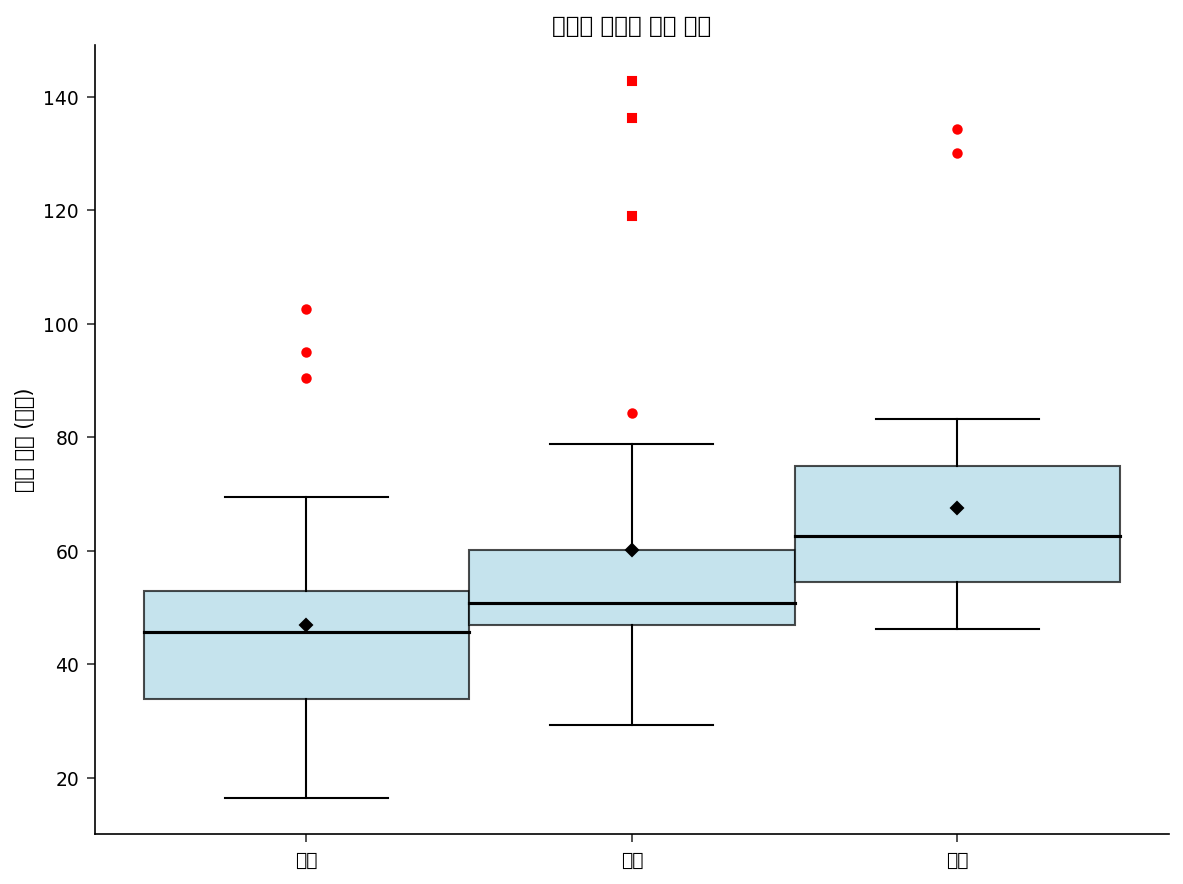

In [3]:
제목 '부서별 응급실 재실 시간';
처리 boxplot 데이터=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
실행;

## 4단계 — 평균 추세선 겹치기

진료과 간 기울기를 명확히 드러내기 위해 `BOXCONNECT=MEAN`을 추가합니다. 그러면 PROC BOXPLOT은 각 상자의 평균(다이아몬드 마커)을 관통하는 연결선을 그려, 세 개의 분리된 분포를 하나의 읽기 쉬운 추세로 바꿉니다. 진료과가 Medicine → Surgery → Trauma 순으로 정렬되어 있으므로, 상승하는 연결선은 평균 재원 시간의 상승을 한 번에 요약합니다. 운영 대시보드에 유용한 단서입니다.

                                     부서별 응급실 재실 시간 - 평균 추세                                      

                       부서별 응급실 재실 시간 - 평균 추세

                                     The BOXPLOT Procedure

Schematic Plots for 재실 시간 (시간)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
내과                   34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
외과                   36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
외상                   30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to 부서별 응급실 재실 시간 - 평균 추세.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


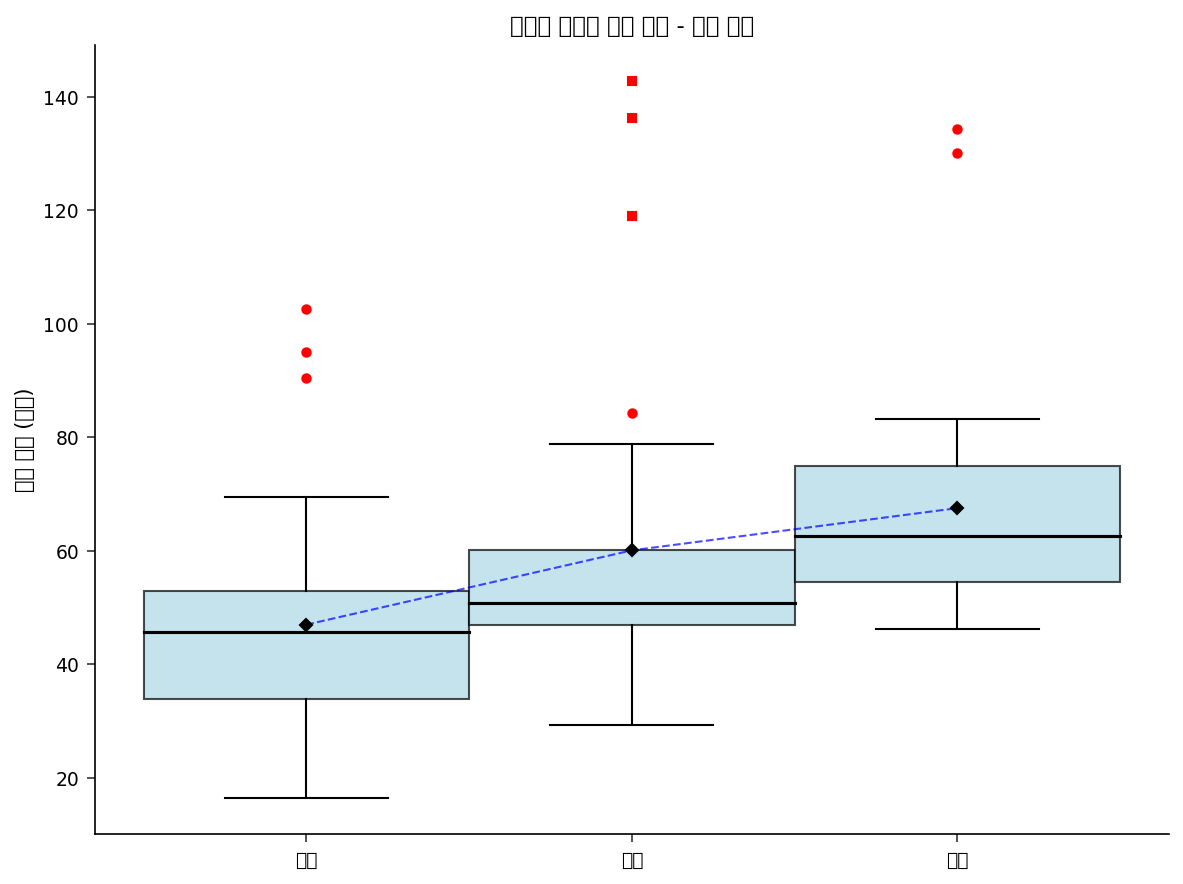

In [4]:
제목 '부서별 응급실 재실 시간 - 평균 추세';
처리 boxplot 데이터=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
실행;

## 5단계 — 가로 배치

동일한 비교는 옆으로 눕혀도 자연스럽게 읽힙니다. `HORIZONTAL`을 추가하면 축이 서로 바뀌어 상자가 왼쪽에서 오른쪽으로 뻗고 반응 변수가 x축에 놓입니다. 진료과 이름이 길거나 많을 때 더 잘 확장되는 배치이며, 많은 운영 대시보드가 선호합니다. 통계는 세로 보기와 동일하고 방향만 바뀝니다.

                                       부서별 응급실 재실 시간 - 수평                                       

                           부서별 응급실 재실 시간 - 수평

                                     The BOXPLOT Procedure

Schematic Plots for 재실 시간 (시간)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
내과                   34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
외과                   36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
외상                   30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to 부서별 응급실 재실 시간 - 수평.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


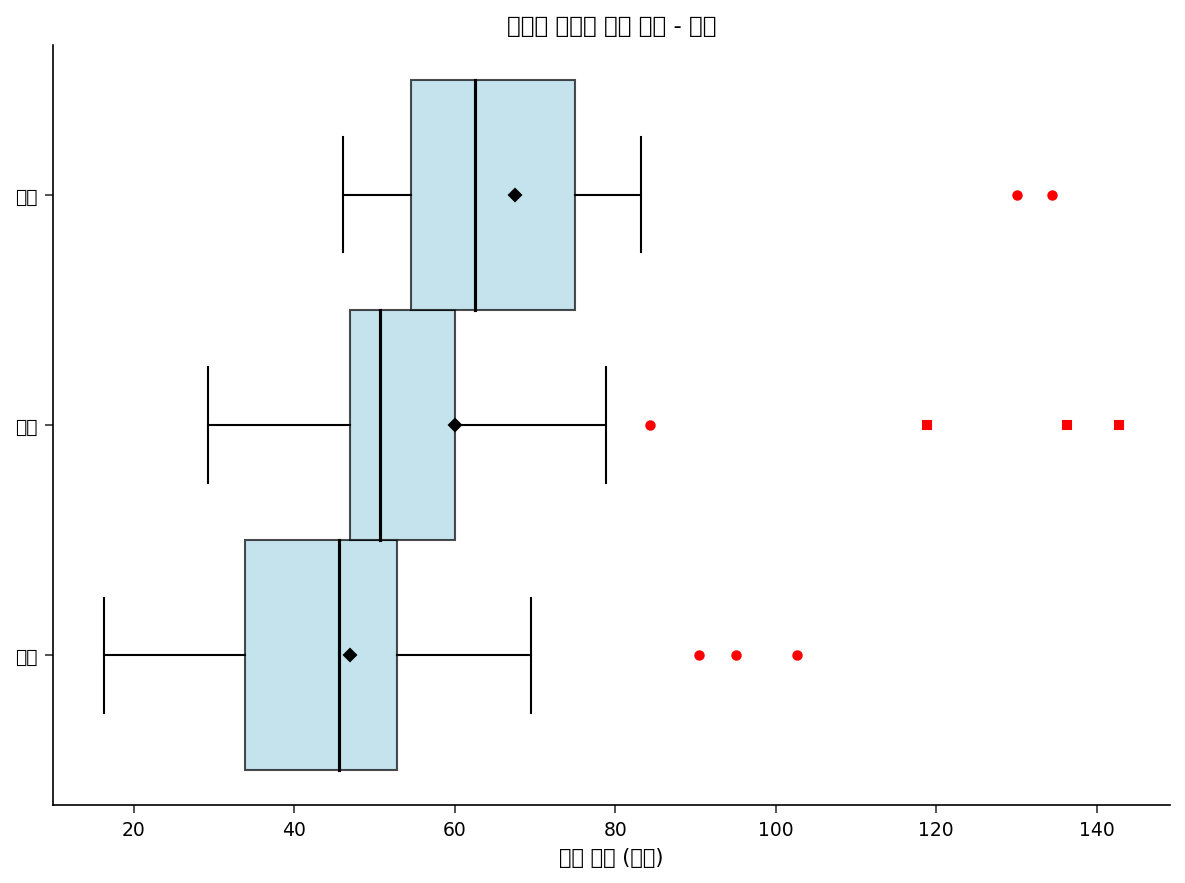

In [5]:
제목 '부서별 응급실 재실 시간 - 수평';
처리 boxplot 데이터=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
실행;

## 결과 해석

상자 그림과 부속 통계 표는 원시 LOS 데이터를 운영상 실행 가능한 그림으로 옮깁니다:

- **뚜렷한 진료과 기울기.** 재원 시간의 중앙값은 세 진료과에 걸쳐 단조롭게 상승합니다: **내과 40.0시간 → 외과 50.4시간 → 외상과 60.5시간**. 평균도 같은 이야기를 전하며(41.6, 54.6, 62.8시간), 4단계의 `BOXCONNECT=MEAN` 선은 그 상승을 하나의 오르는 추세로 그립니다. 외상과 환자는 평균적으로 내과 환자보다 약 50% 더 오래 머뭅니다.

- **변동성은 중앙값만큼 중요합니다.** 사분위 범위(상자 높이)는 내과에서 가장 넓고(Q1 32.8시간부터 Q3 51.2시간까지, 18.3시간 폭) 외상과에서 가장 좁습니다(Q1 54.5시간부터 Q3 68.5시간까지, 14.0시간 폭). 따라서 내과는 재원이 가장 짧은 진료과일 뿐 아니라 가장 예측하기 어려운 진료과이며, 이는 병상 관리 예측을 복잡하게 만드는 특성입니다.

- **이상값은 대기 사례를 표시합니다.** 개략 수염은 1.5 × IQR에서 멈추므로, 외과의 위쪽 수염을 넘는 빨간 점 세 개(최고 84.3시간)는 진정한 장기 재원 사례로 두드러집니다. 바로 병상 시간을 불균형하게 소모하는 대기 사례입니다. 이 표본에서 내과와 외상과는 수염을 넘는 점이 없습니다.

- **범위는 수용 계획 이야기를 전합니다.** 관측된 재원은 내과 16.3–69.5시간, 외과 29.3–84.3시간, 외상과 46.1–83.2시간에 걸칩니다. 외상과는 결코 짧은 재원을 만들지 않으며(최소값 46.1시간이 내과의 중앙값을 초과), 이는 운영팀이 가장 자원 집약적인 진료과에서 기대할 만한 결과입니다.

이 관점들을 종합하면 응급실 리더십 팀은 인력 배치와 수용 계획에 대해 방어 가능하고 분포를 인식하는 근거를 얻으며, 이는 진료과별 평균 LOS만 비교하는 것보다 훨씬 유익합니다.